# 02 - EDA: Labels and Time

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATASET_DIR = Path("../dataset")
FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = DATASET_DIR / "elliptic_txs_features.csv"
CLASSES_PATH = DATASET_DIR / "elliptic_txs_classes.csv"

In [2]:
time_df = pd.read_csv(
    FEATURES_PATH,
    header=None,
    usecols=[0, 1],
    names=["tx_id", "time_step"],
)

classes_df = pd.read_csv(CLASSES_PATH).rename(
    columns={"txId": "tx_id", "class": "label"}
)

transactions_df = time_df.merge(
    classes_df,
    on="tx_id",
    how="left",
    validate="one_to_one",
)

label_mapping = {
    "1": "illicit",
    "2": "licit",
    "unknown": "unknown",
}

transactions_df["label_name"] = transactions_df["label"].astype(str).map(label_mapping)

display(transactions_df.head())
print("Shape:", transactions_df.shape)

,tx_id,time_step,label,label_name
0,230425980,1,unknown,unknown
1,5530458,1,unknown,unknown
2,232022460,1,unknown,unknown
3,232438397,1,2,licit
4,230460314,1,unknown,unknown


Shape: (203769, 4)


In [3]:
assert transactions_df.shape == (203_769, 4)
assert transactions_df["tx_id"].is_unique
assert transactions_df["label_name"].notna().all()
assert sorted(transactions_df["time_step"].unique()) == list(range(1, 50))

print("Data loaded correctly.")

Data loaded correctly.


In [4]:
LABEL_ORDER = ["illicit", "licit", "unknown"]

label_counts = transactions_df["label_name"].value_counts().reindex(LABEL_ORDER)

label_summary = pd.DataFrame(
    {
        "count": label_counts,
        "share_of_all_transactions": label_counts / len(transactions_df),
    }
)

display(
    label_summary.style.format(
        {
            "share_of_all_transactions": "{:.2%}",
        }
    )
)

,count,share_of_all_transactions
label_name,,
illicit,4545,2.23%
licit,42019,20.62%
unknown,157205,77.15%


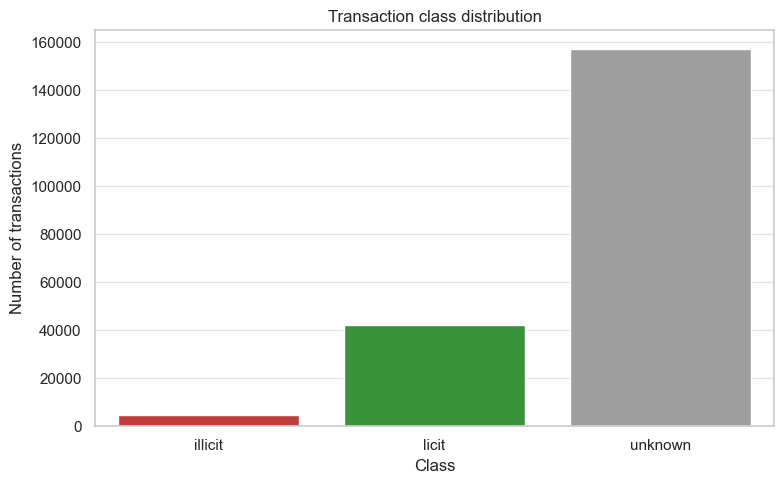

In [5]:
CLASS_COLORS = {
    "illicit": "#d62728",
    "licit": "#2ca02c",
    "unknown": "#9e9e9e",
}

plt.figure(figsize=(8, 5))

sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    hue=label_counts.index,
    palette=CLASS_COLORS,
    legend=False,
)

plt.title("Transaction class distribution")
plt.xlabel("Class")
plt.ylabel("Number of transactions")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=150)
plt.show()

In [6]:
labeled_df = transactions_df[transactions_df["label_name"] != "unknown"].copy()

labeled_counts = labeled_df["label_name"].value_counts().reindex(["illicit", "licit"])

illicit_share_all = label_counts["illicit"] / len(transactions_df)
illicit_share_labeled = labeled_counts["illicit"] / len(labeled_df)

print("All transactions:", len(transactions_df))
print("Labeled transactions:", len(labeled_df))
print("Illicit share among all transactions:", f"{illicit_share_all:.2%}")
print("Illicit share among labeled transactions:", f"{illicit_share_labeled:.2%}")

All transactions: 203769
Labeled transactions: 46564
Illicit share among all transactions: 2.23%
Illicit share among labeled transactions: 9.76%


In [7]:
time_summary = (
    transactions_df.groupby(["time_step", "label_name"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=LABEL_ORDER, fill_value=0)
)

time_summary["labeled"] = time_summary["illicit"] + time_summary["licit"]

time_summary["total"] = time_summary["labeled"] + time_summary["unknown"]

time_summary["illicit_share_among_labeled"] = (
    time_summary["illicit"] / time_summary["labeled"]
)

display(time_summary.head())

label_name,illicit,licit,unknown,labeled,total,illicit_share_among_labeled
time_step,,,,,,
1,17,2130,5733,2147,7880,0.007918
2,18,1099,3427,1117,4544,0.016115
3,11,1268,5342,1279,6621,0.008600
4,30,1410,4253,1440,5693,0.020833
5,8,1874,4921,1882,6803,0.004251


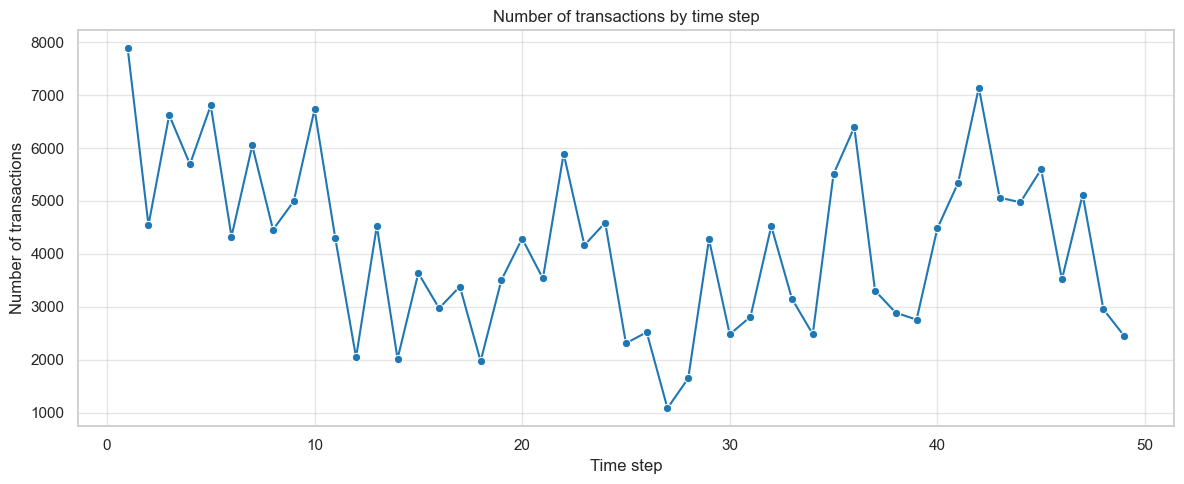

In [8]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=time_summary,
    x=time_summary.index,
    y="total",
    marker="o",
    color="#1f77b4",
)

plt.title("Number of transactions by time step")
plt.xlabel("Time step")
plt.ylabel("Number of transactions")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "transactions_by_time_step.png", dpi=150)
plt.show()

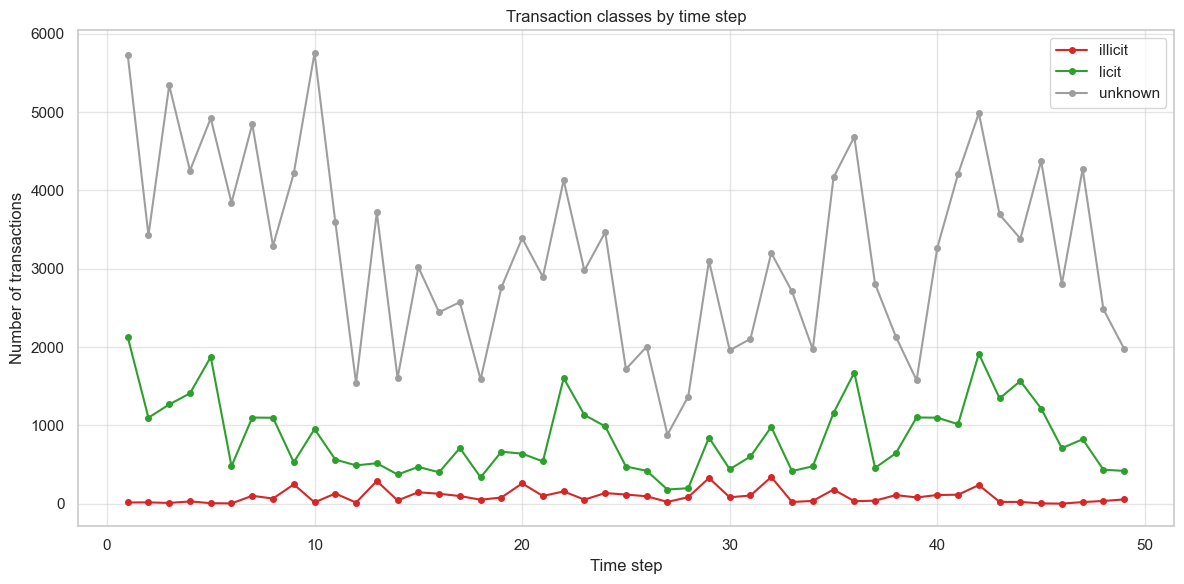

In [9]:
plt.figure(figsize=(12, 6))

for label in LABEL_ORDER:
    plt.plot(
        time_summary.index,
        time_summary[label],
        marker="o",
        markersize=4,
        label=label,
        color=CLASS_COLORS[label],
    )

plt.title("Transaction classes by time step")
plt.xlabel("Time step")
plt.ylabel("Number of transactions")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "classes_by_time_step.png", dpi=150)
plt.show()

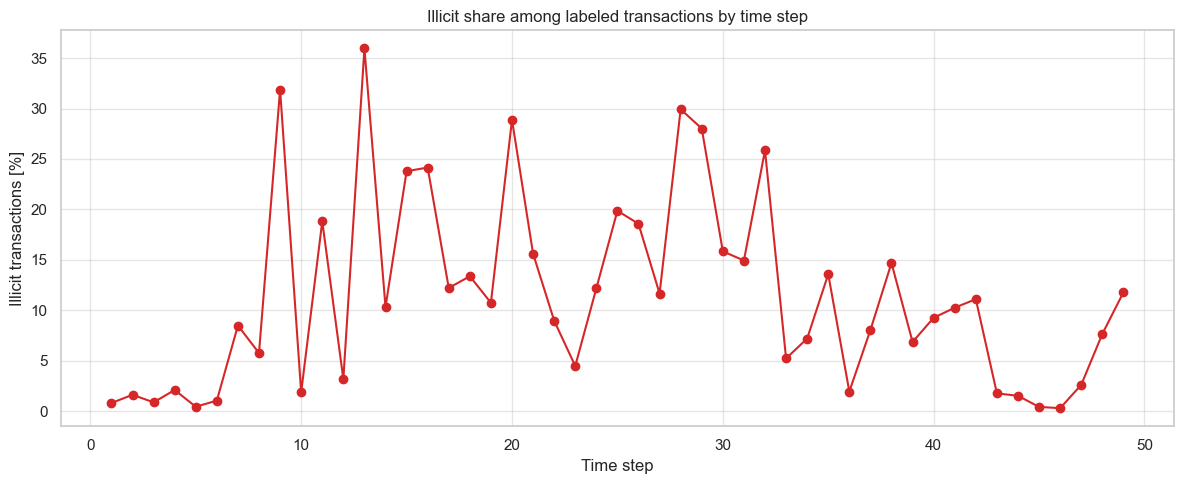

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    time_summary.index,
    time_summary["illicit_share_among_labeled"] * 100,
    marker="o",
    color=CLASS_COLORS["illicit"],
)

plt.title("Illicit share among labeled transactions by time step")
plt.xlabel("Time step")
plt.ylabel("Illicit transactions [%]")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "illicit_share_by_time_step.png", dpi=150)
plt.show()

In [11]:
assert label_counts.to_dict() == {
    "illicit": 4_545,
    "licit": 42_019,
    "unknown": 157_205,
}

print("All label and time EDA checks passed.")

All label and time EDA checks passed.
